In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
words = (
    open(
        "/content/drive/MyDrive/Colab Notebooks/neural-networks-from-scratch/names.txt",
        "r",
    )
    .read()
    .splitlines()
)

# words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [6]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [57]:
# build the dataset

block_size = (
    3  # context length: how many characters do we take to predict the next one?
)
X, Y = [], []
for w in words[:5]:
    print(w)
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix]  # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... ---> e
..e ---> m
.em ---> m
emm ---> a
mma ---> .
olivia
... ---> o
..o ---> l
.ol ---> i
oli ---> v
liv ---> i
ivi ---> a
via ---> .
ava
... ---> a
..a ---> v
.av ---> a
ava ---> .
isabella
... ---> i
..i ---> s
.is ---> a
isa ---> b
sab ---> e
abe ---> l
bel ---> l
ell ---> a
lla ---> .
sophia
... ---> s
..s ---> o
.so ---> p
sop ---> h
oph ---> i
phi ---> a
hia ---> .


In [58]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [59]:
C = torch.randn((27, 2))

In [60]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [61]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [62]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [63]:
h

tensor([[-0.3889,  0.4486,  0.9591,  ...,  0.6901, -0.6298, -1.0000],
        [ 0.9908, -0.6835,  0.9916,  ...,  0.8506, -0.6940, -0.9999],
        [ 0.5390,  0.9963,  0.9903,  ...,  0.9990, -0.9961, -0.0486],
        ...,
        [ 0.9915,  0.8705,  0.4323,  ...,  0.9851, -0.9932,  0.9847],
        [-0.9874,  0.6937, -0.8324,  ...,  0.9470,  0.8764, -0.9999],
        [-0.2689, -0.9900, -0.9999,  ..., -0.9540,  0.9999, -1.0000]])

In [64]:
h.shape

torch.Size([32, 100])

In [65]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [66]:
logits = h @ W2 + b2
logits.shape

torch.Size([32, 27])

In [67]:
counts = logits.exp()

In [68]:
prob = counts / counts.sum(1, keepdim=True)

In [69]:
prob.shape

torch.Size([32, 27])

In [70]:
loss = -prob[torch.arange(32), Y].log().mean()
loss.item()

18.031131744384766

#### Full implementation of the MLP

In [ ]:
# build the dataset
block_size = (
    3  # context length: how many characters do we take to predict the next one?
)

def build_dataset(words):
    X, Y = [], []
    for w in words:
        # print(w)
        context = [0] * block_size
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '--->', itos[ix])
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [73]:
Xtr.shape, Ytr.shape 

(torch.Size([182625, 3]), torch.Size([182625]))

In [74]:
g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [75]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [77]:
for p in parameters:
  p.requires_grad = True

In [78]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [79]:
lri = []
lossi = []
stepi = []

In [89]:
for i in range(200000):
    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass
    emb = C[Xtr[ix]]  # (32, 3, 10)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 200)
    logits = h @ W2 + b2  # (32, 27)
    loss = F.cross_entropy(logits, Ytr[ix])
    # print(loss.item())

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())

# print(loss.item())

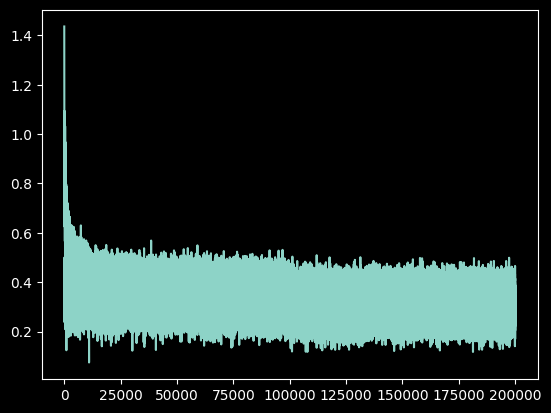

In [90]:
plt.plot(stepi, lossi)

In [91]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.0743, grad_fn=<NllLossBackward0>)

In [92]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1305, grad_fn=<NllLossBackward0>)

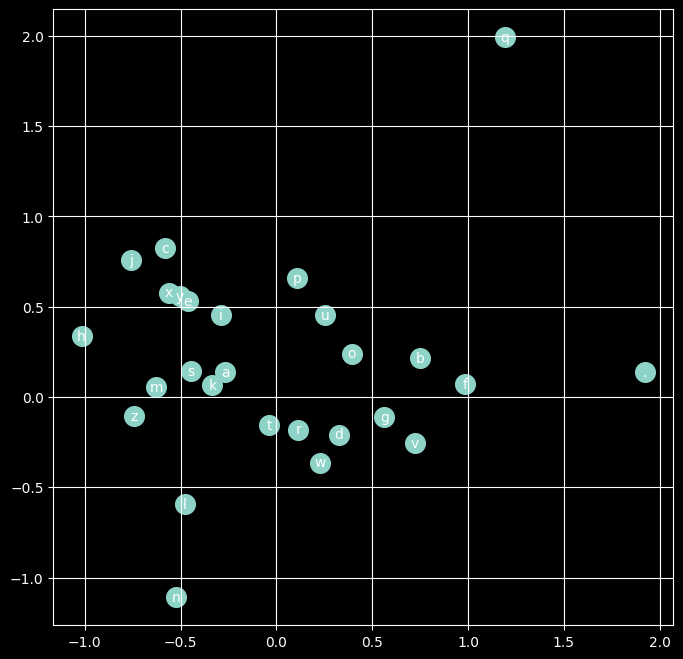

In [93]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

#### sample from the model

In [94]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [95]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size  
    while True:
        emb = C[torch.tensor([context])]  
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    print("".join(itos[i] for i in out))

carlah.
amelle.
khy.
myli.
taty.
skanden.
jazhutwulferric.
kaeli.
ner.
kentzeriivia.
leggyd.
luge.
catessan.
sulisea.
jadique.
jerogierrynix.
kaellissabee.
deciia.
gileena.
frana.
